# Test completo di archivio, analisi e visualizzazione Sudoku

Questo notebook verifica l'intero flusso:

1. genera un nuovo Sudoku con soluzione unica;
2. lo salva nell'archivio;
3. lo ricarica dal file;
4. esegue l'analisi completa, che al primo accesso deve essere calcolata e salvata;
5. visualizza il risultato in tutti i modi disponibili;
6. richiede nuovamente la stessa analisi e verifica che venga restituita dalla cache in memoria.

Il notebook presuppone questi moduli nello stesso progetto:

- `sudoku_solver.py`
- `sudoku_archive.py`
- `sudoku_visualization.py`


In [38]:
import random
import time
import numpy as np

import matplotlib.pyplot as plt
import pandas as pd

import sudoku_solver as ss
import sudoku_archive as sa
import sudoku_visualization as sv
import sudoku_generator as sg

plt.rcParams["figure.figsize"] = (7, 7)


## 3. Caricamento del Sudoku

Il Sudoku viene ricaricato usando il nome assegnato. La griglia caricata viene confrontata con quella generata.


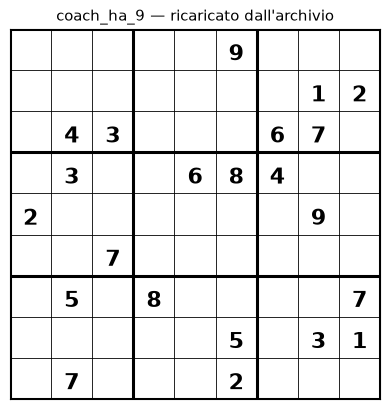

In [39]:
#loaded_info = sa.load_sudoku('coach_dev_1')
loaded_info = sa.load_last_sudoku()
loaded_puzzle = loaded_info["grid"]

sv.draw_grid(
    loaded_puzzle,
    title=f"{loaded_info['name']} — ricaricato dall'archivio",
)
plt.show()


## 4. Prima analisi completa


In [ ]:
start = time.perf_counter()

first_result = sa.analyse_puzzle_cached(
    loaded_puzzle,
    name=loaded_info["name"],
    analysis_mode="profile",
    profile_difficulty_window=2
)

first_elapsed = time.perf_counter() - start

print("Prima analisi completata")
print("Tempo:", round(first_elapsed, 4), "secondi")
print("Stato:", first_result["status"])
print("Valutazione:", first_result["grading"])
print("Numero di step:", len(first_result["chain"]))
print(f"ID: {first_result['puzzle_id']}")


## 6. Catena di difficoltà

Mostra il livello di difficoltà usato a ogni step e il numero complessivo di passaggi per livello.


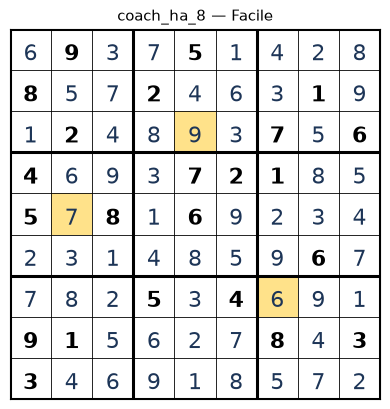

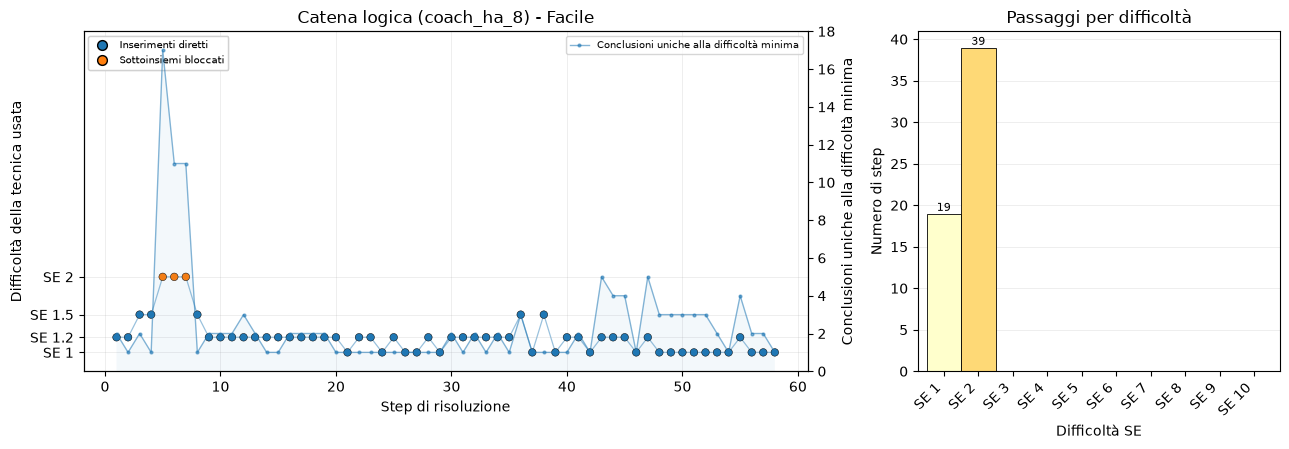

In [ ]:
clues = ss.trivialize_greedy(loaded_puzzle)
sv.draw_grid(
    first_result["solved_grid"],
    given_mask=(first_result["original"] != 0),
    title=(
        f"{first_result['name']} — "
        f"{first_result['grading']['label']}"
    ),
    highlight=clues['highlight']
)
plt.show()
sv.plot_difficulty_chain(first_result)
plt.show()

## 7. Passaggio più difficile

Viene visualizzato lo stato della griglia in corrispondenza del passaggio con difficoltà massima.


Indice: 4
Step: 5
Tecnica: Direct Hidden Pair
Difficoltà: 2.0
Descrizione: Nel row, i numeri [4, 5] formano un Direct Hidden Pair. Le eliminazioni risultanti lasciano 2 come Hidden Single in R8C5.


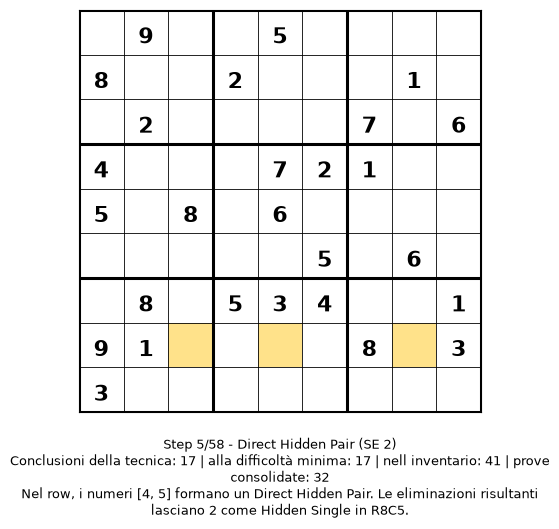

In [ ]:
if first_result["chain"]:
    hardest_index = max(
        range(len(first_result["chain"])),
        key=lambda index: first_result["chain"][index]["difficulty"],
    )

    hardest_move = first_result["chain"][hardest_index]

    print("Indice:", hardest_index)
    print("Step:", hardest_move["step"])
    print("Tecnica:", hardest_move["technique"])
    print("Difficoltà:", hardest_move["difficulty"])
    print("Descrizione:", hardest_move["description"])

    sv.draw_step(first_result, hardest_index)
else:
    print("Nessun passaggio disponibile.")


## 10. Attività delle tecniche durante la risoluzione

Se `sudoku_visualization.py` contiene `plot_technique_activity`, viene mostrata la heatmap con:

- righe: tecniche;
- colonne: step;
- valori: numero di applicazioni disponibili in quello stato.

Le analisi devono contenere `applicable_by_technique` perché questa visualizzazione sia significativa.


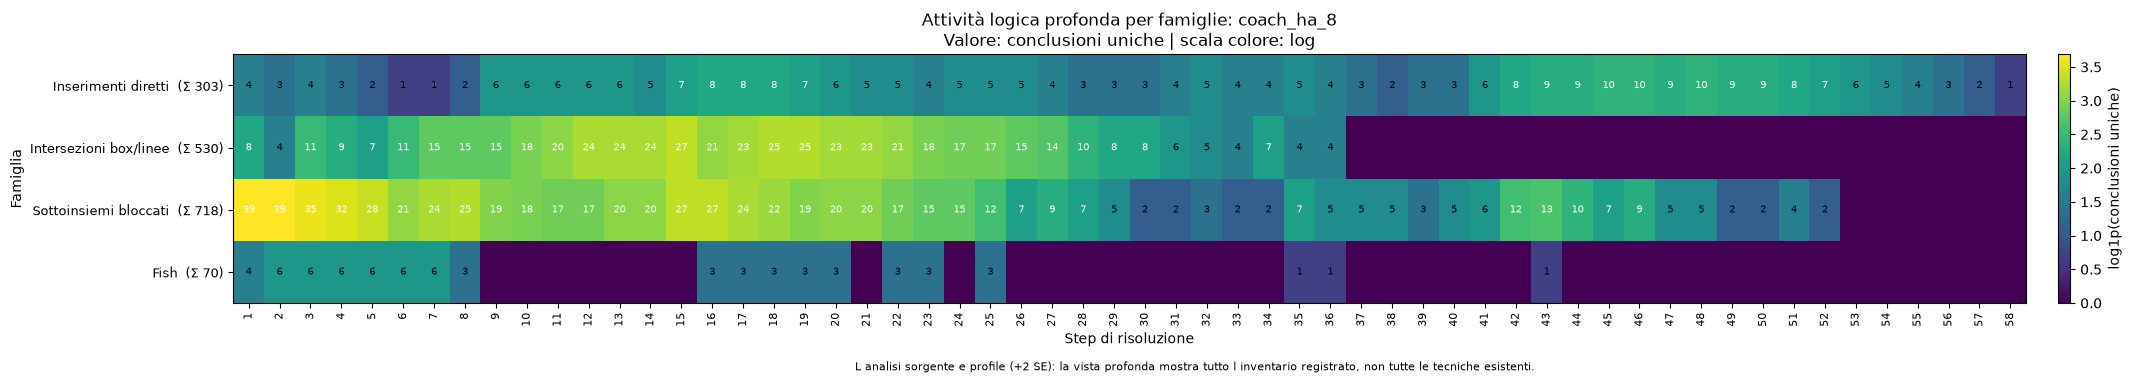

In [ ]:
sv.plot_technique_activity(
        first_result,
        depth='deep',
        view='extended',
        metric="conclusions",
        scale="log",
        annotate="auto",
    );